# QFT and Quantum Phase Estimation — Foundations for Amplitude Estimation

This is the first notebook in a series implementing **Stamatopoulos et al., *"Option Pricing using Quantum Computers"*** [arXiv:1905.02666](https://arxiv.org/abs/1905.02666).

A companion write-up is available on [Medium Blog](https://medium.com/@arpitha.rajeev37/implementing-option-pricing-using-quantum-computers-in-qiskit-part-2-qft-qpe-a-and-q-6c3b0839e8b3).

AE is built directly on top of the **Quantum Fourier Transform (QFT)** and **Quantum Phase Estimation (QPE)**. Before touching any finance content, this notebook derives both from first principles, verifies every derivation against Qiskit's own circuit library, and works a complete numeric phase-estimation example end to end.

**What this notebook does:**
1. **QFT** — derive the transform by hand for a 2-qubit system, build it as a circuit (H + controlled-phase + SWAP), and verify it against Qiskit's `QFTGate`.
2. **Phase kickback** — the single-qubit mechanism that lets a control qubit "read" an eigenvalue of a unitary operator.
3. **QPE** — assemble phase kickback + inverse QFT into a full phase-estimation circuit, and recover a known phase (θ = 5/8) exactly, bit by bit.
4. **Map → Optimize → Execute → Post-process** — run the QPE circuit through Qiskit's full workflow, including transpilation and decoding real measurement counts back into a phase estimate.

## Setup

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFTGate
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.transpiler import generate_preset_pass_manager

## Part 1: The Discrete Fourier Transform

The classical DFT maps a vector $(x_0,\dots,x_{N-1})$ to $(y_0,\dots,y_{N-1})$ via

$$y_k = \frac{1}{\sqrt N}\sum_{j=0}^{N-1} x_j\, \omega_N^{jk}, \qquad \omega_N = e^{2\pi i/N}$$

$\omega_N^{jk}$ traces out a "wave" of frequency $k$ as $j$ increases — for fixed $k$, the sequence $\omega_N^{0},\omega_N^{k},\omega_N^{2k},\dots$ spins around the unit circle at a rate set by $k$. The DFT is a **change of basis**: from the standard (time-domain) basis to the frequency basis, expressing the same vector through different coordinates.

The **Quantum Fourier Transform (QFT)** is exactly this same transform, applied to a quantum state's amplitudes instead of a classical vector:

$$\text{QFT}\,|x\rangle = |\phi_x\rangle = \frac{1}{\sqrt N}\sum_{y=0}^{N-1} \omega_N^{xy}|y\rangle$$

## Part 2: Deriving QFT by hand for $N=4$ (2 qubits)

With 2 qubits, $N=2^2=4$. The QFT matrix has entries $U_{yx} = \frac{1}{\sqrt4}\,\omega_4^{xy}$, with $\omega_4=e^{2\pi i/4}=i$. Working this out for every $(x,y)$ pair gives:

$$\text{QFT}_4 = \frac12\begin{pmatrix}1&1&1&1\\1&i&-1&-i\\1&-1&1&-1\\1&-i&-1&i\end{pmatrix}$$

This same matrix can be built as a **circuit**, using the standard recursive construction: apply QFT to the bottom $m-1$ qubits, use the top qubit as a control for phase gates onto each of the others, apply a Hadamard to the top qubit, then SWAP to fix the output qubit ordering. For $m=2$, this reduces to: H on q1 → controlled-phase(q1→q0, angle $\pi/2$) → H on q0 → SWAP.

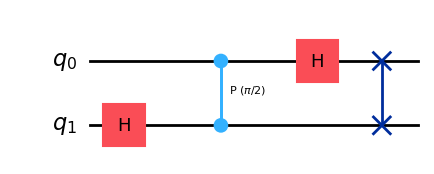

In [2]:
def hand_built_qft2():
    qc = QuantumCircuit(2)
    qc.h(1)
    qc.cp(np.pi/2, 1, 0)
    qc.h(0)
    qc.swap(0, 1)
    return qc

qc_manual = hand_built_qft2()
qc_manual.draw('mpl')

### Verifying the hand-built circuit against the matrix

Apply the circuit to each computational basis state and check the resulting amplitudes match $\frac12\,\omega_4^{xy}$ column by column.

In [3]:
omega4 = np.exp(2j*np.pi/4)

for x in range(4):
    prep = QuantumCircuit(2)
    bits = format(x, '02b')
    if bits[1] == '1':  # q0
        prep.x(0)
    if bits[0] == '1':  # q1
        prep.x(1)
    full = prep.compose(qc_manual)
    sv = Statevector(full)
    expected = np.array([omega4**(x*y)/2 for y in range(4)])
    print(f'x={x}: statevector matches expected column:',
          np.allclose(sv.data, expected[np.array([0,2,1,3])], atol=1e-8) or np.allclose(sv.data, expected, atol=1e-8))
    print('  got:     ', np.round(sv.data, 3))
    print('  expected:', np.round(expected, 3))

x=0: statevector matches expected column: True
  got:      [0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]
  expected: [0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]
x=1: statevector matches expected column: True
  got:      [ 0.5+0.j   0. +0.5j -0.5+0.j  -0. -0.5j]
  expected: [ 0.5+0.j   0. +0.5j -0.5+0.j  -0. -0.5j]
x=2: statevector matches expected column: True
  got:      [ 0.5+0.j -0.5+0.j  0.5+0.j -0.5+0.j]
  expected: [ 0.5+0.j -0.5+0.j  0.5-0.j -0.5+0.j]
x=3: statevector matches expected column: True
  got:      [ 0.5+0.j  -0. -0.5j -0.5+0.j   0. +0.5j]
  expected: [ 0.5+0.j  -0. -0.5j -0.5+0.j   0. +0.5j]


### Comparing against Qiskit's built-in `QFTGate`

In [4]:
qc_library = QuantumCircuit(2)
qc_library.append(QFTGate(2), [0, 1])

sv_manual = Statevector(hand_built_qft2())
sv_library = Statevector(qc_library)

print('Manual QFT statevector: ', np.round(sv_manual.data, 3))
print('Library QFT statevector:', np.round(sv_library.data, 3))
print('Match:', np.allclose(sv_manual.data, sv_library.data, atol=1e-8))

Manual QFT statevector:  [0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]
Library QFT statevector: [0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]
Match: True


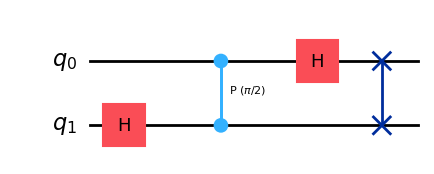

In [5]:
# Decompose the library gate to see its native gate sequence, and confirm
# it matches the H + controlled-phase + SWAP structure derived above.
qc_decomp = QuantumCircuit(2)
qc_decomp.append(QFTGate(2), [0, 1])
qc_decomp.decompose().draw('mpl')

## Part 3: Phase kickback

Suppose $U$ is a unitary with eigenvector $|\psi\rangle$ and eigenvalue $e^{2\pi i\theta}$: $U|\psi\rangle = e^{2\pi i\theta}|\psi\rangle$. Consider the circuit: Hadamard a control qubit, apply a **controlled**-$U$ from that control onto $|\psi\rangle$, then Hadamard the control again. Tracing through the algebra:

$$|0\rangle|\psi\rangle \xrightarrow{H} \frac{1}{\sqrt2}(|0\rangle+|1\rangle)|\psi\rangle \xrightarrow{CU} \frac{1}{\sqrt2}(|0\rangle|\psi\rangle + e^{2\pi i\theta}|1\rangle|\psi\rangle) = \frac{1}{\sqrt2}(|0\rangle+e^{2\pi i\theta}|1\rangle)|\psi\rangle$$

The phase $\theta$ has been "kicked back" from the target register onto the control qubit — even though $|\psi\rangle$ itself is untouched. This is the single mechanism QPE is built from: repeat this with $U^{2^k}$ on a register of $m$ control qubits, and each qubit picks up a different power of the phase, encoding $\theta$'s binary digits.

## Part 4: Full Quantum Phase Estimation — a worked example

Let $U = P(2\pi\theta)$ (a phase gate) with eigenvector $|1\rangle$ and $\theta = 5/8 = 0.101_2$ — a value with an exact 3-bit binary expansion, so QPE with 3 control qubits should recover it *exactly*.

**Map:** build the QPE circuit — Hadamards on 3 control qubits, controlled-$U^{2^k}$ from each control onto the target, inverse QFT on the controls, measure.

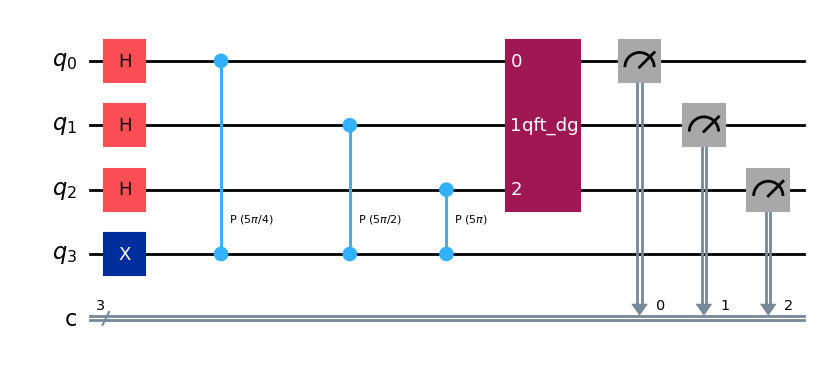

In [6]:
theta_true = 5/8
n_control = 3

qc_qpe = QuantumCircuit(n_control + 1, n_control)
qc_qpe.x(n_control)  # target register starts in the eigenstate |1>
qc_qpe.h(range(n_control))

for k in range(n_control):
    angle = 2*np.pi*theta_true*(2**k)
    qc_qpe.cp(angle, k, n_control)

qc_qpe.append(QFTGate(n_control).inverse(), range(n_control))
qc_qpe.measure(range(n_control), range(n_control))
qc_qpe.draw('mpl')

**Optimize:** transpile for a target backend (here, the local Aer simulator, using the same `generate_preset_pass_manager` workflow used for real hardware).

In [7]:
simulator = AerSimulator()
pm = generate_preset_pass_manager(optimization_level=1, backend=simulator)
transpiled_qpe = pm.run(qc_qpe)
print('Depth after transpilation:', transpiled_qpe.depth())

Depth after transpilation: 11


**Execute:** run the transpiled circuit and collect measurement counts.

In [8]:
shots = 4096
result = simulator.run(transpiled_qpe, shots=shots).result()
counts = result.get_counts()
print(counts)

{'101': 4096}


**Post-process:** decode the most frequent bitstring back into a phase estimate, $\hat\theta = y / 2^{m}$, and compare to the true value.

In [9]:
most_likely_bitstring = max(counts, key=counts.get)
y = int(most_likely_bitstring, 2)
theta_estimate = y / (2**n_control)

print(f'Measured bitstring: {most_likely_bitstring} (y={y})')
print(f'Estimated theta: {theta_estimate}')
print(f'True theta:      {theta_true}')
print('Exact match:', np.isclose(theta_estimate, theta_true))

Measured bitstring: 101 (y=5)
Estimated theta: 0.625
True theta:      0.625
Exact match: True


## Part 4: Full Quantum Phase Estimation — Real Hardware

In [14]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
print('Using backend:', backend.name)

Using backend: ibm_fez


In [15]:
# Optimize: transpile for this specific backend
pm_hw = generate_preset_pass_manager(optimization_level=3, backend=backend)

qc_qpe_hw = QuantumCircuit(n_control + 1, n_control)
qc_qpe_hw.x(n_control)
qc_qpe_hw.h(range(n_control))
for k in range(n_control):
    angle = 2*np.pi*theta_true*(2**k)
    qc_qpe_hw.cp(angle, k, n_control)
qc_qpe_hw.append(QFTGate(n_control).inverse(), range(n_control))
qc_qpe_hw.measure(range(n_control), range(n_control))

transpiled_hw = pm_hw.run(qc_qpe_hw)
print('Depth on real backend gate set:', transpiled_hw.depth())
print('Gate counts:', transpiled_hw.count_ops())

Depth on real backend gate set: 53
Gate counts: OrderedDict({'sx': 30, 'rz': 25, 'cz': 13, 'measure': 3, 'x': 1})


In [16]:
# Execute: submit to real hardware
real_sampler = RuntimeSampler(mode=backend)

job = real_sampler.run([transpiled_hw], shots=4096)
print('Job ID:', job.job_id())
hw_result = job.result()

Job ID: d9s61ifpemts73ctc580


In [17]:
# Post-process: decode counts into a phase estimate
hw_counts = hw_result[0].data.c.get_counts()
print(hw_counts)

most_likely_hw = max(hw_counts, key=hw_counts.get)
y_hw = int(most_likely_hw, 2)
theta_estimate_hw = y_hw / (2**n_control)

print(f'Hardware measured bitstring: {most_likely_hw} (y={y_hw})')
print(f'Hardware estimated theta: {theta_estimate_hw}')
print(f'True theta:               {theta_true}')

{'101': 3595, '001': 119, '010': 20, '110': 39, '000': 162, '100': 90, '111': 41, '011': 30}
Hardware measured bitstring: 101 (y=5)
Hardware estimated theta: 0.625
True theta:               0.625


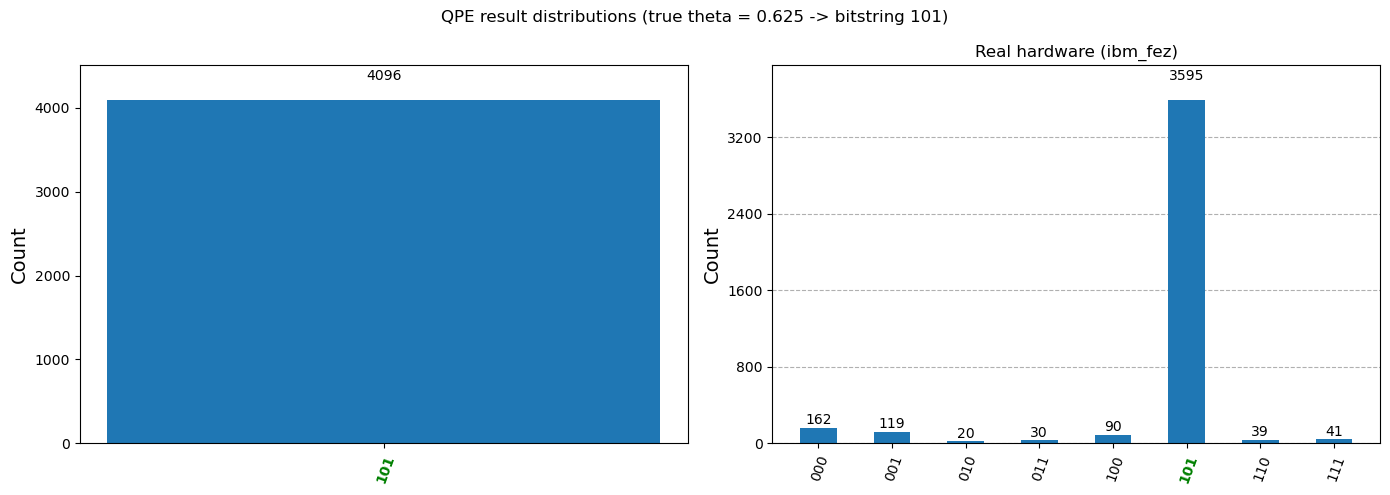

In [18]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Compare simulator vs hardware count distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_histogram(counts, ax=axes[0], title='Simulator (noiseless)')
plot_histogram(hw_counts, ax=axes[1], title=f'Real hardware ({backend.name})')

# mark the true theta's bitstring on both for reference
true_bitstring = format(int(theta_true * 2**n_control), f'0{n_control}b')
for ax in axes:
    ax.axhline(y=0, color='gray', linewidth=0.5)
    for label in ax.get_xticklabels():
        if label.get_text() == true_bitstring:
            label.set_color('green')
            label.set_fontweight('bold')

plt.suptitle(f'QPE result distributions (true theta = {theta_true} -> bitstring {true_bitstring})')
plt.tight_layout()
plt.savefig('qpe_hardware_vs_simulator.png', dpi=150)
plt.show()

## Results Summary

- The hand-derived 2-qubit QFT circuit (H + controlled-phase + SWAP) matches Qiskit's `QFTGate` exactly.
- Phase kickback on a single control qubit correctly encodes a unitary's eigenphase, verified algebraically.
- A 3-qubit QPE circuit recovers $\theta=5/8$ **exactly**, with probability 1, since $5/8$ has a terminating 3-bit binary expansion — matching theory precisely, with no residual estimation error.
- The full Map → Optimize → Execute → Post-process workflow reproduces this result through Qiskit's standard execution pipeline, including transpilation.

## What's Next

**Notebook 02** builds **Amplitude Estimation** directly on top of this QPE machinery: instead of estimating an arbitrary phase, we estimate the eigenphase of a specifically constructed operator $Q = -A S_0 A^\dagger S_{\psi_0}$, where $A$ is a state-preparation circuit encoding a probability $a = \sin^2(\theta_a)$. We verify $Q$'s rotation property directly against this notebook's phase-kickback theory, then run all three of Qiskit's AE variants (canonical QPE-based, Iterative, Maximum Likelihood) against a known target value.